In [32]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

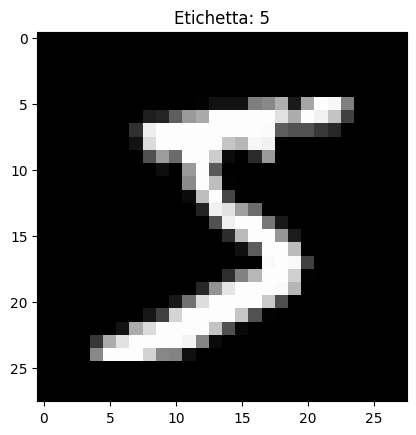

In [33]:
# Caricamento del dataset MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Visualizzazione di un esempio

plt.imshow(X_train[0], cmap='gray')

plt.title(f'Etichetta: {y_train[0]}')

plt.show()


# Normalizzazione dei dati, le reti neurali funzionano SOLO con dati normalizzati

X_train = X_train.astype('float32') / 255

X_test = X_test.astype('float32') / 255


# Reshape dei dati

X_train = X_train.reshape(-1, 28*28)

X_test = X_test.reshape(-1, 28*28)


# Conversione delle etichette in formato one-hotencoding

y_train = to_categorical(y_train, num_classes=10)

y_test = to_categorical(y_test, num_classes=10)

In [34]:
# Creazione del modello

model = Sequential()


# Aggiunta degli strati

model.add(Dense(units=128, activation='relu', input_shape=(784,)))

model.add(Dropout(0.3))

model.add(Dense(units=64, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(units=10, activation='softmax'))



In [35]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
opt = Adam(learning_rate=0.001)

In [37]:
model.compile(optimizer=opt,

              loss='categorical_crossentropy',

              metrics=['accuracy'])

In [38]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Stop training if val_loss doesn't improve for 7 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

# 2. Halve the Learning Rate if val_loss doesn't improve for 3 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,      # Factor by which the learning rate will be reduced (0.5 = half)
    patience=3,      # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-6,     # Lower bound on the learning rate
    verbose=1
)

In [39]:
history = model.fit(X_train, y_train,

                    epochs=100,

                    batch_size=64,

                    validation_split=0.1,

                    callbacks=[early_stop, reduce_lr])

Epoch 1/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8597 - loss: 0.4642 - val_accuracy: 0.9617 - val_loss: 0.1307 - learning_rate: 0.0010
Epoch 2/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9354 - loss: 0.2212 - val_accuracy: 0.9690 - val_loss: 0.1072 - learning_rate: 0.0010
Epoch 3/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9471 - loss: 0.1756 - val_accuracy: 0.9745 - val_loss: 0.0864 - learning_rate: 0.0010
Epoch 4/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9560 - loss: 0.1487 - val_accuracy: 0.9757 - val_loss: 0.0804 - learning_rate: 0.0010
Epoch 5/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9610 - loss: 0.1317 - val_accuracy: 0.9753 - val_loss: 0.0764 - learning_rate: 0.0010
Epoch 6/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9628 - loss: 0.1214 - val_accuracy: 0.9773 - val_loss: 0.0726 - learning_rate: 0.0010
Epoch 7/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9668 - loss: 0

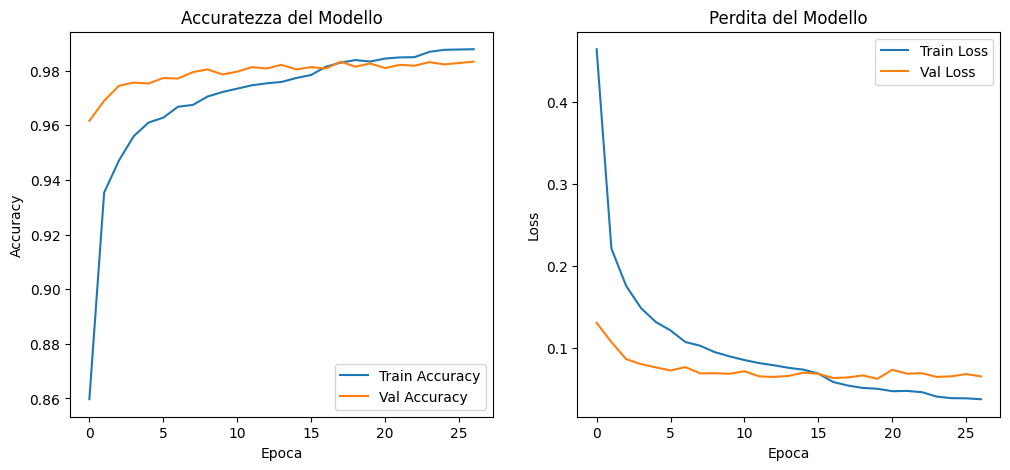

In [40]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [41]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Perdita sul test set: {test_loss:.4f}')

print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9804 - loss: 0.0765
Perdita sul test set: 0.0765
Accuratezza sul test set: 0.9804
